<a href="https://colab.research.google.com/github/aryanx-byte/Task1-level-1-codeveda-/blob/main/level2Task1_and_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Regression Analysis

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
file_path = '/content/4) house Prediction Data Set.csv'
df = pd.read_csv(file_path, sep='\s+', header=None)

print("Dataset loaded successfully. Here are the first 5 rows:")
display(df.head())

Dataset loaded successfully. Here are the first 5 rows:


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1971/3254618812.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', header=None)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 1 columns):
 #   Column                                                                                            Non-Null Count  Dtype 
---  ------                                                                                            --------------  ----- 
 0    0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00  505 non-null    object
dtypes: object(1)
memory usage: 4.1+ KB


In [7]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


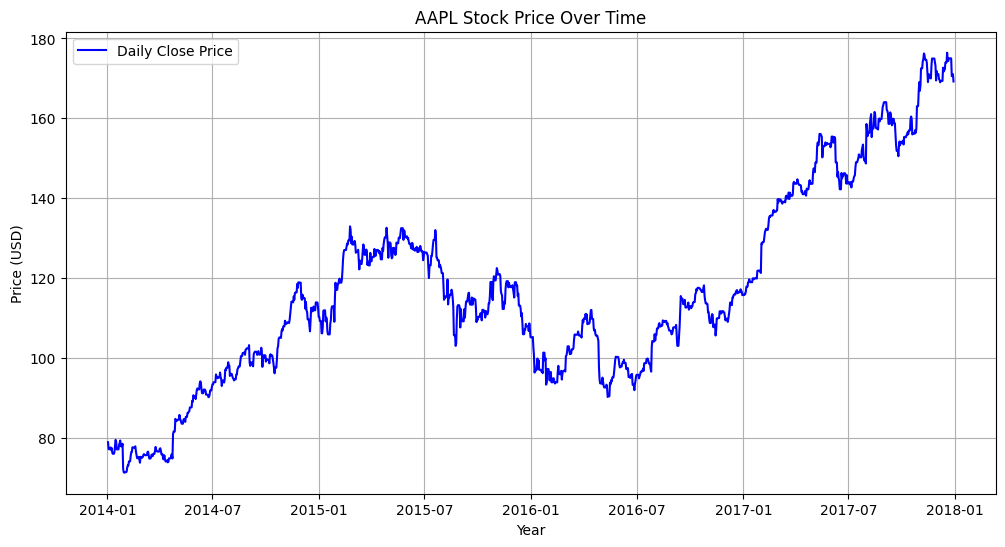

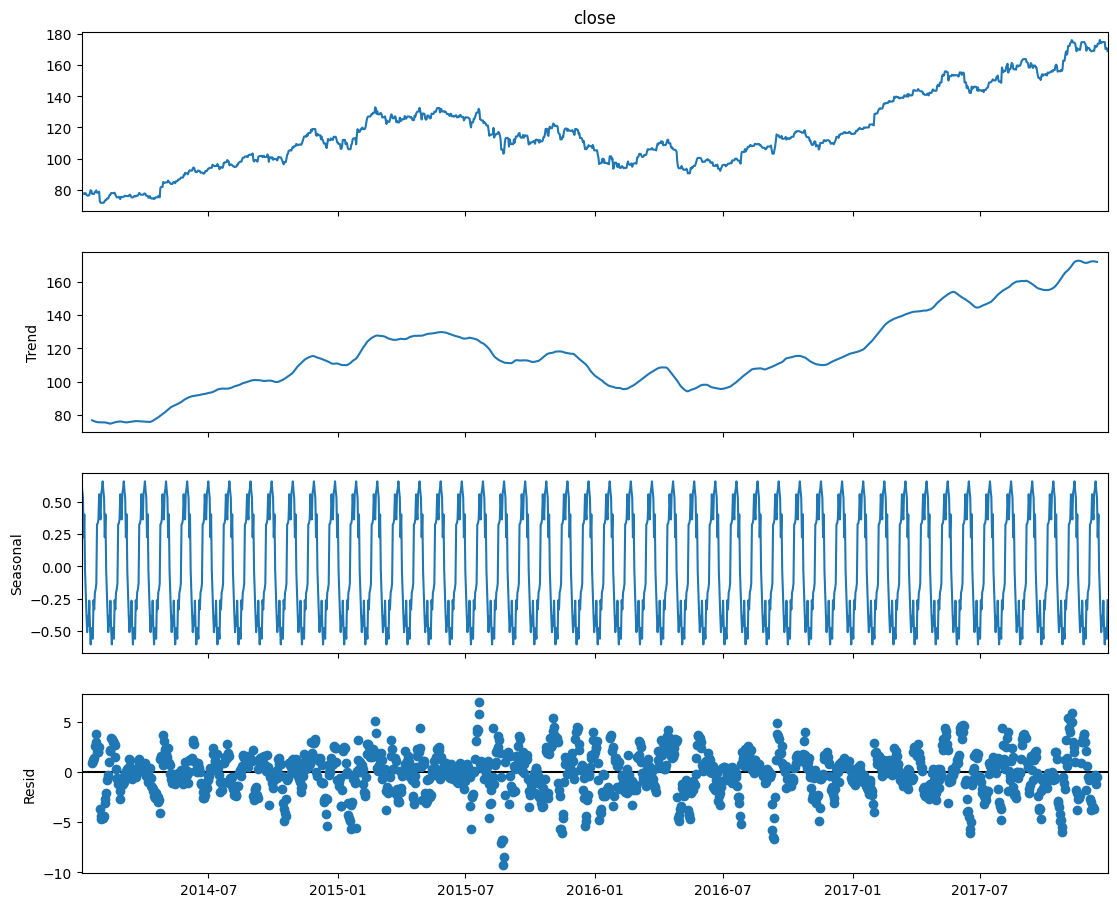

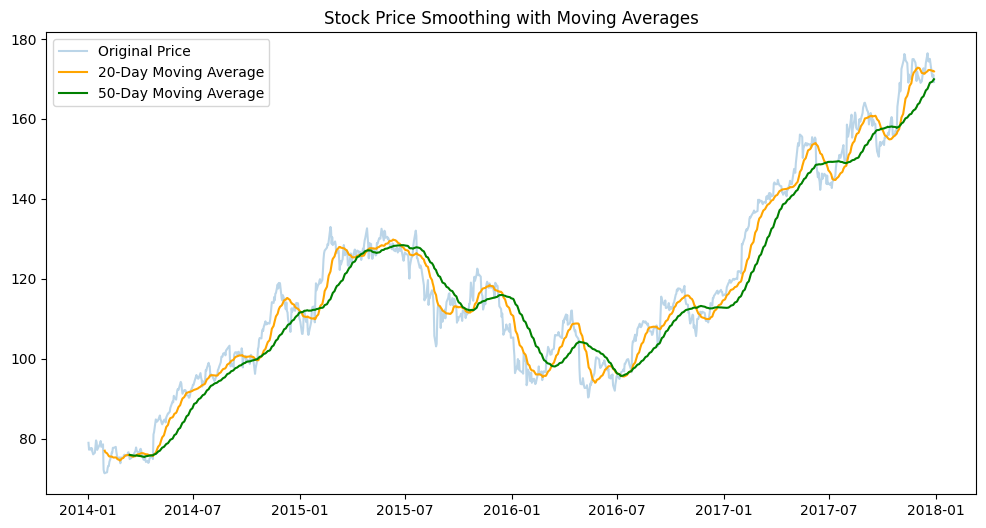

In [10]:
# Time Series Analysis

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Data Load

df = pd.read_csv('2) Stock Prices Data Set.csv')

# 2. Data Preprocessing
df['date'] = pd.to_datetime(df['date'])


aapl_df = df[df['symbol'] == 'AAPL'].sort_values('date')


aapl_df = aapl_df.set_index('date')

# 3. Resampling (Decomposition ke liye zaroori)
# Stock data  weekends
aapl_series = aapl_df['close'].resample('D').ffill()

# 4. Original Data
plt.figure(figsize=(12, 6))
plt.plot(aapl_series, color='blue', label='Daily Close Price')
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# 5. Time-Series Decomposition (Trend, Seasonality, Residuals)

result = seasonal_decompose(aapl_series, model='additive', period=30)

# Decomposition plots
fig = result.plot()
fig.set_size_inches(12, 10)
plt.show()

# 6. Moving Average Smoothing
# 20-day and 50-day  (short-term aur long-term trends)
aapl_df['MA20'] = aapl_df['close'].rolling(window=20).mean()
aapl_df['MA50'] = aapl_df['close'].rolling(window=50).mean()

# Moving Average Plotting
plt.figure(figsize=(12, 6))
plt.plot(aapl_df['close'], label='Original Price', alpha=0.3) # Original
plt.plot(aapl_df['MA20'], label='20-Day Moving Average', color='orange')
plt.plot(aapl_df['MA50'], label='50-Day Moving Average', color='green')
plt.title('Stock Price Smoothing with Moving Averages')
plt.legend()
plt.show()